dataset link: https://www.kaggle.com/datasets/umerrtx/machine-failure-prediction-using-sensor-data

# Dataset description:
This dataset contains sensor data collected from various machines, with the aim of predicting machine failures in advance. It includes a variety of sensor readings as well as the recorded machine failures.

Columns Description footfall: The number of people or objects passing by the machine. tempMode: The temperature mode or setting of the machine. AQ: Air quality index near the machine. USS: Ultrasonic sensor data, indicating proximity measurements. CS: Current sensor readings, indicating the electrical current usage of the machine. VOC: Volatile organic compounds level detected near the machine. RP: Rotational position or RPM (revolutions per minute) of the machine parts. IP: Input pressure to the machine. Temperature: The operating temperature of the machine. fail: Binary indicator of machine failure (1 for failure, 0 for no failure).

# Problem statement:
Here I have to built a predictive model so tha the upcoming machine failures can be predicted for reducing the maintanance cost drastically.

# Importing necessary libraries

In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

# Importing the data 

In [8]:
data = pd.read_csv(r"C:\Users\Public\My projects\notebook\Notebook\Predictive maintainance\data.csv")
df = data.copy() #to avoid changing the original data
print("Head of the dataset:")
print(df.head(5))
print()
print()
print("Tail of the dataset:")
print(df.tail(5))

Head of the dataset:
   footfall  tempMode  AQ  USS  CS  VOC  RP  IP  Temperature  fail
0         0         7   7    1   6    6  36   3            1     1
1       190         1   3    3   5    1  20   4            1     0
2        31         7   2    2   6    1  24   6            1     0
3        83         4   3    4   5    1  28   6            1     0
4       640         7   5    6   4    0  68   6            1     0


Tail of the dataset:
     footfall  tempMode  AQ  USS  CS  VOC  RP  IP  Temperature  fail
939         0         7   7    1   6    4  73   6           24     1
940         0         7   5    2   6    6  50   6           24     1
941         0         3   6    2   7    5  43   6           24     1
942         0         6   6    2   5    6  46   7           24     1
943        18         7   4    2   6    3  61   7           24     1


# Checking the attribes name

In [9]:
df.columns

Index(['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP',
       'Temperature', 'fail'],
      dtype='object')

# Now checking the distribution of each attributes

c:\Users\Public\My projects\venv\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


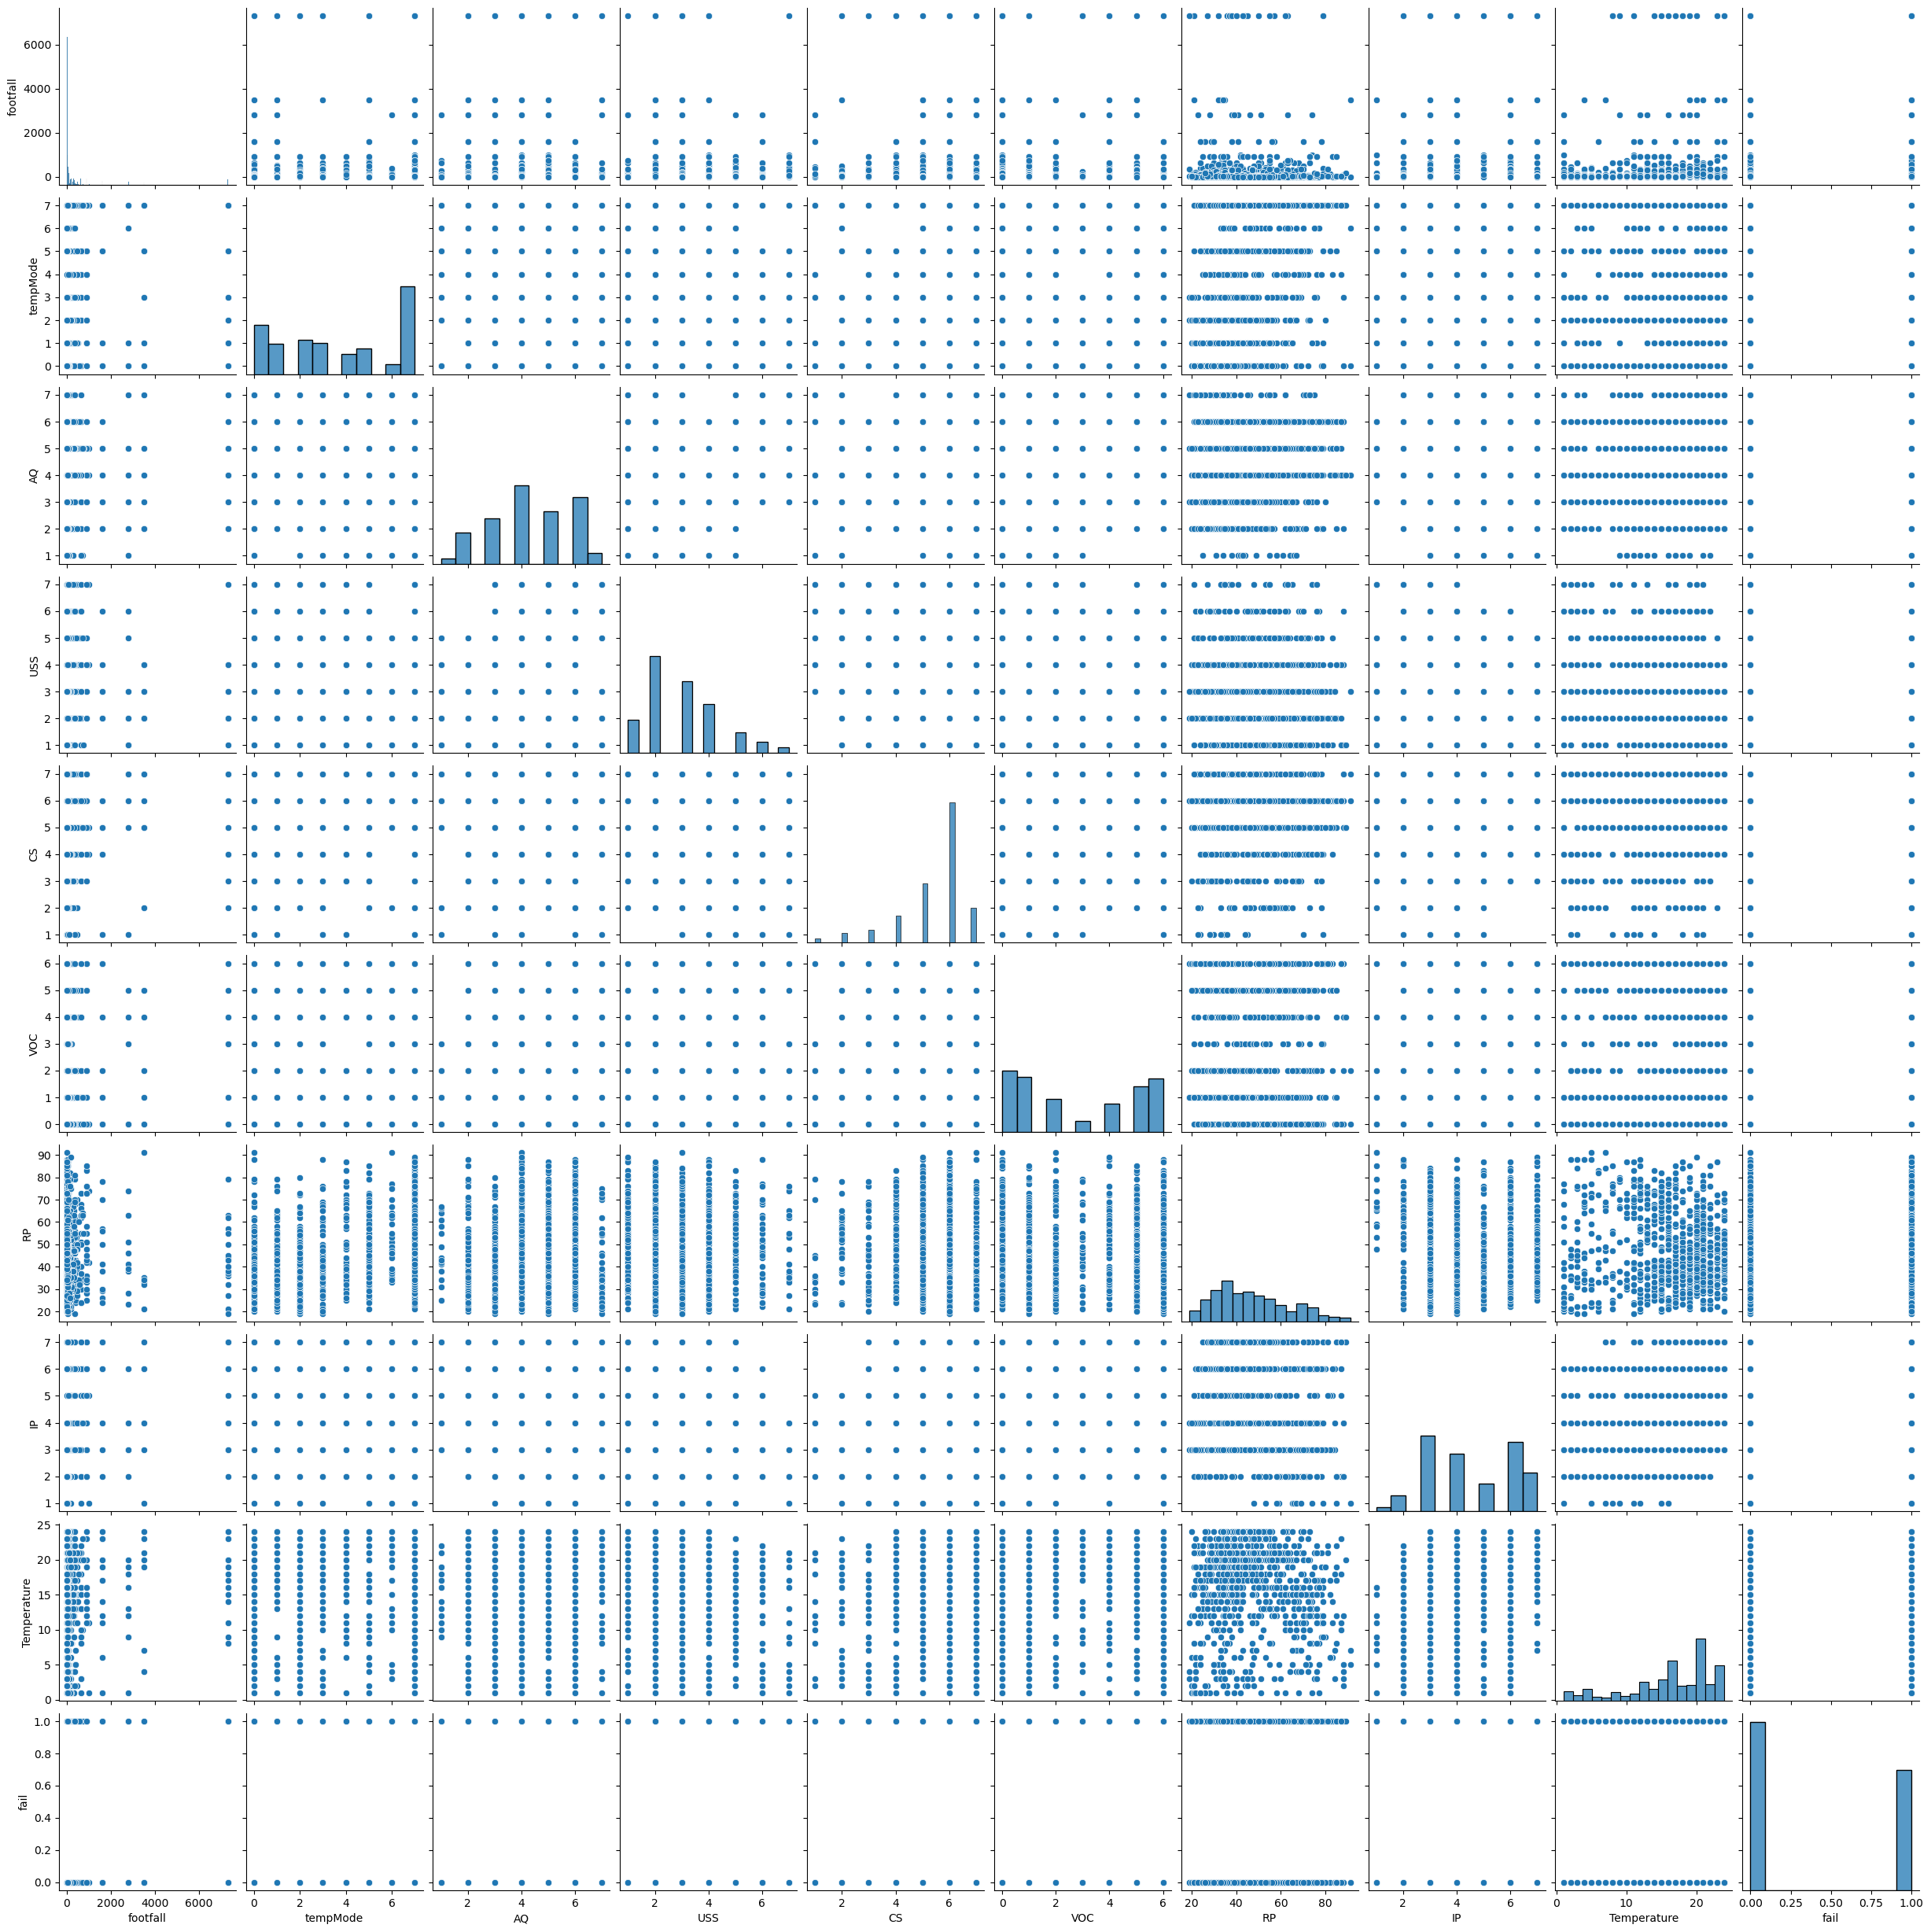

In [10]:
sns.pairplot(df)

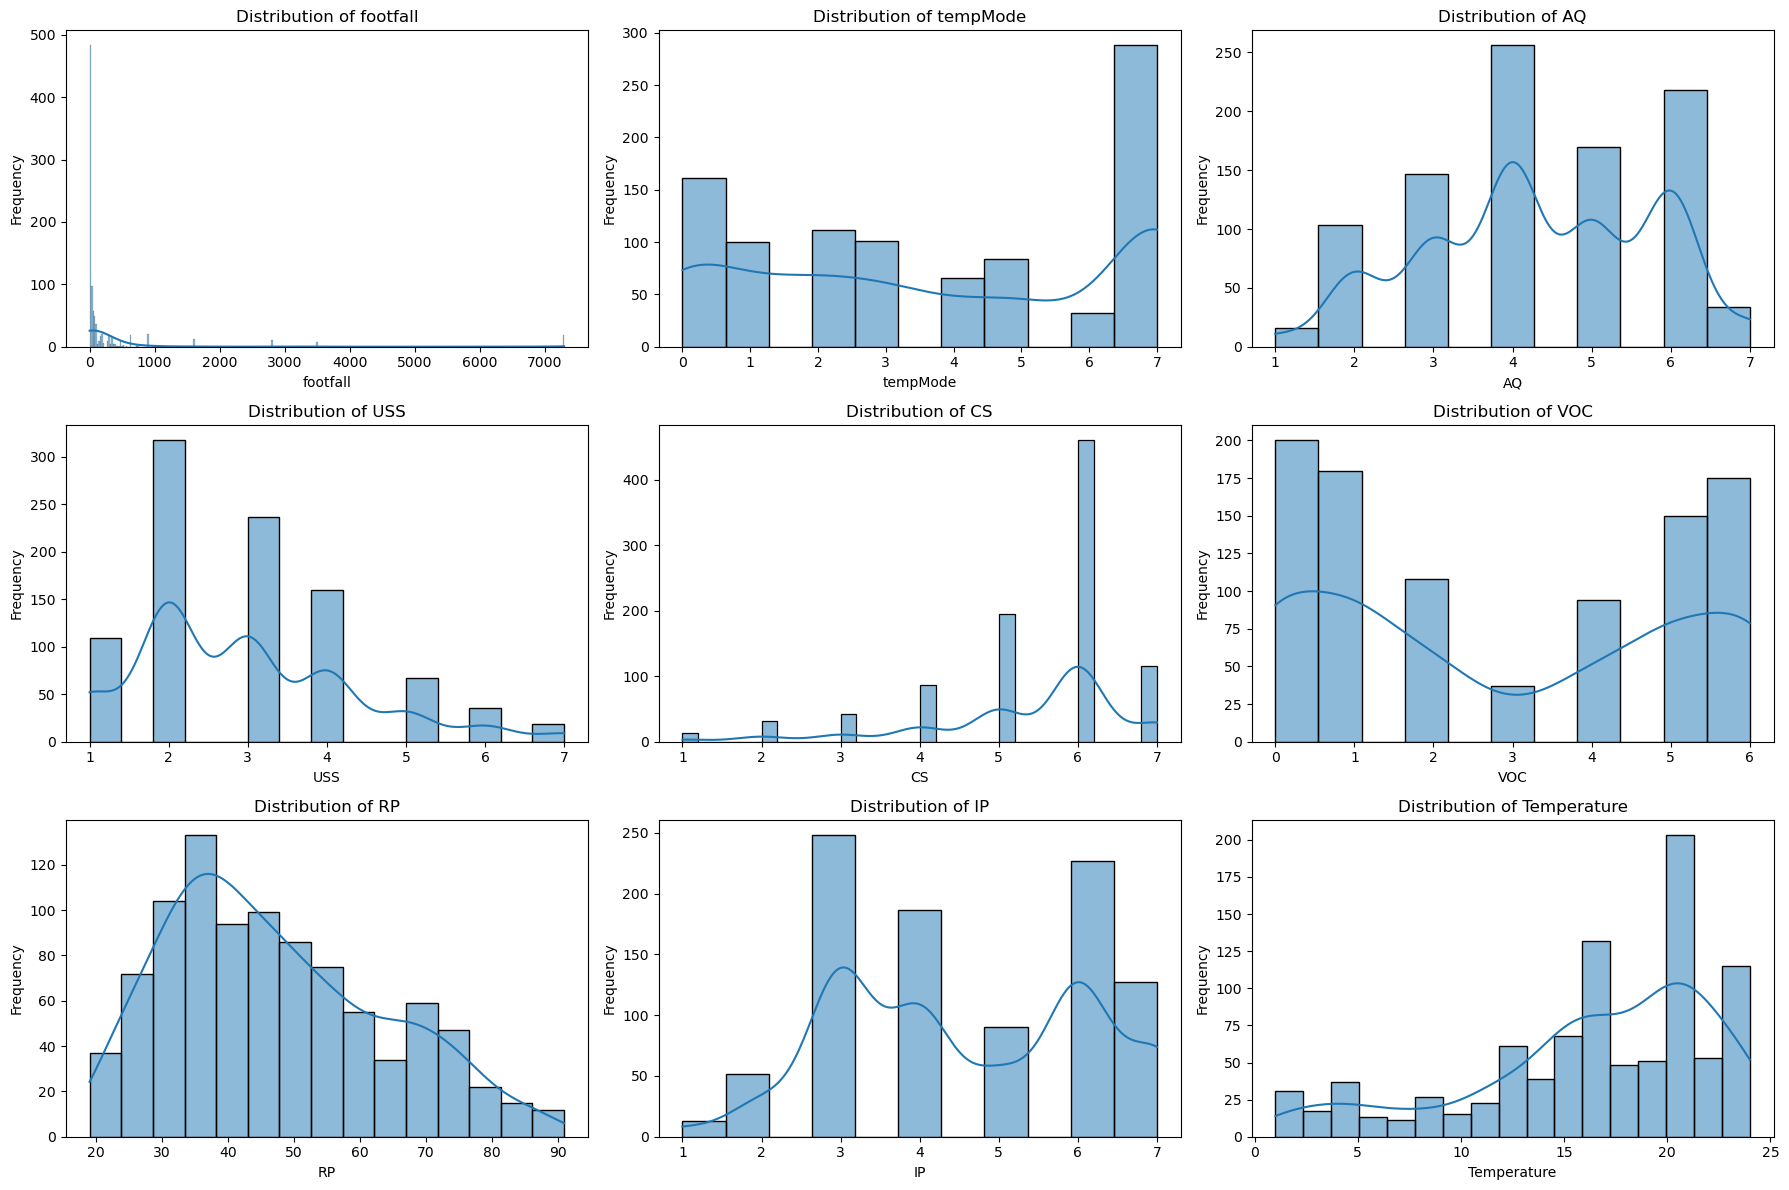

In [11]:
columns = df.iloc[:,:-1].columns
n = len(columns)
ncols = 3
nrows = (n + ncols - 1) // ncols  # auto calculating rows

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.savefig("Histogram with KDE.png")
plt.tight_layout()
plt.show()


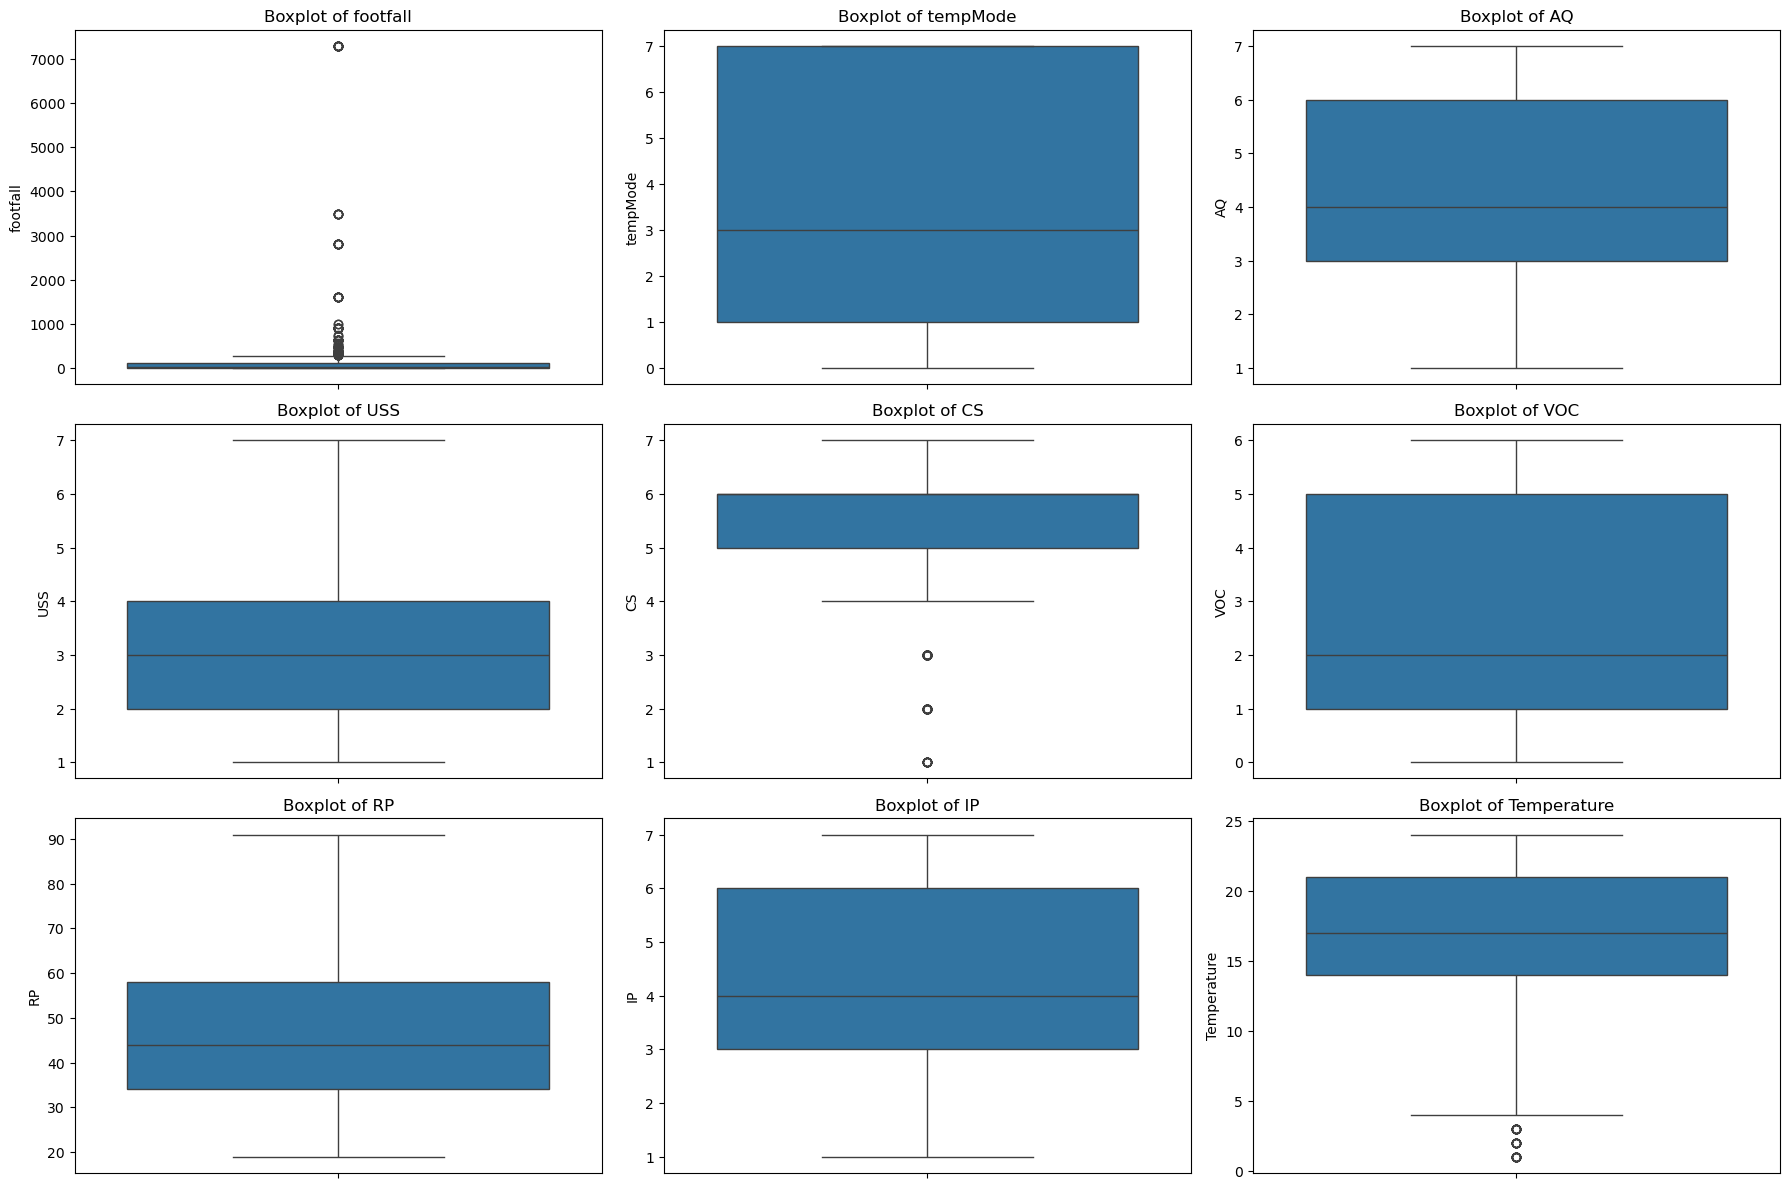

In [12]:
columns = df.iloc[:,:-1].columns
n = len(columns)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.savefig("Boxplot.png")
plt.tight_layout()
plt.show()


# Now checking the unique values for each attributes

In [13]:
for col in columns:
    print(f"The total unique values in {col} are: {df[col].unique()}")

The total unique values in footfall are: [   0  190   31   83  640  110  100  180 2800 1600  330 1000  130    5
   33   19   74   12  390   40    3  450  350   64   62   11    4   35
  270   45    6    2 3500   67   30  400   15   22   32   59  170    1
   53   16   27   84  200   20 7300   13    9   44   51   29  630   50
  720   24   55   63   71  900  370  470   47    8  290   10   93  510
   56    7  140   14  310   37   23  360   87   42   70  520   54   75
   34   76  430  150   25   18  740   81  160  220   26   88   66  570
   17]
The total unique values in tempMode are: [7 1 4 3 0 5 2 6]
The total unique values in AQ are: [7 3 2 5 4 6 1]
The total unique values in USS are: [1 3 2 4 6 7 5]
The total unique values in CS are: [6 5 4 3 7 2 1]
The total unique values in VOC are: [6 1 0 4 3 5 2]
The total unique values in RP are: [36 20 24 28 68 21 77 31 39 26 22 42 74 62 58 51 88 27 44 45 40 48 34 60
 32 33 57 84 75 19 47 35 43 76 46 38 69 67 72 37 30 64 59 55 65 73 91 71
 83 53 82

# Findings:
There is need for scaling of footfall, temperature and RP attributes while others
shall be encoded using one hot encoding

# Now need to check the incosistensis of the data

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     944 non-null    int64
 1   tempMode     944 non-null    int64
 2   AQ           944 non-null    int64
 3   USS          944 non-null    int64
 4   CS           944 non-null    int64
 5   VOC          944 non-null    int64
 6   RP           944 non-null    int64
 7   IP           944 non-null    int64
 8   Temperature  944 non-null    int64
 9   fail         944 non-null    int64
dtypes: int64(10)
memory usage: 73.9 KB


In [15]:
df.isnull().sum()

footfall       0
tempMode       0
AQ             0
USS            0
CS             0
VOC            0
RP             0
IP             0
Temperature    0
fail           0
dtype: int64

# No incosistencies here

# Now checking the data balances

In [16]:
df["fail"].value_counts()

fail
0    551
1    393
Name: count, dtype: int64

In [17]:
rows = df.shape[0]
not_fail = df[df["fail"]==0].shape[0]
fail = rows - not_fail
print("Total failed in percentage: "+ str((rows - not_fail)/rows * 100) + " %")
print("Total not failed in percentage: "+ str(not_fail/rows * 100) + " %")


Total failed in percentage: 41.63135593220339 %
Total not failed in percentage: 58.368644067796616 %


# Now lets visualize it

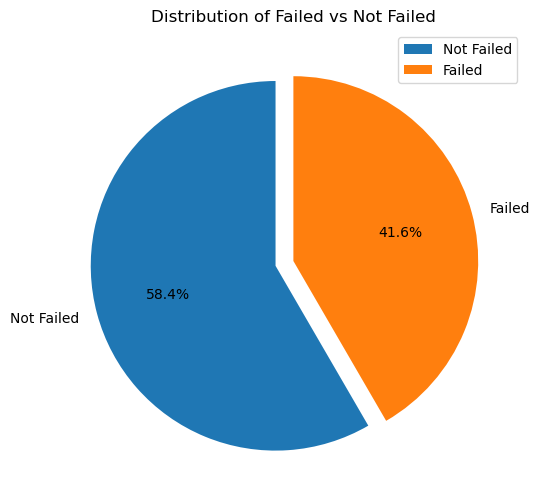

In [18]:
data = [not_fail, fail]
plt.figure(figsize=(8,6))
plt.pie(data, labels=["Not Failed", "Failed"], autopct='%1.1f%%',explode=[0.1, 0], startangle=90)
plt.title("Distribution of Failed vs Not Failed")
plt.legend()
plt.savefig("Distribution of Failed vs Not Failed.png")
plt.show()

# Findings:
Not severely imbalaced data so we can go for class weight parameter